# Intent Classification on CLINC150 with Deep Neural Networks

**Deep Neural Networks - course project.**

**Goal:** build a proof-of-concept intent classifier with DNNs and evaluate whether it could
replace the LLM-based intent classifier used in my master's thesis project **SettleIn**
(an Agentic AI system for immigrant assistance in Serbia,
[github.com/IlorDash/settle-in](https://github.com/IlorDash/settle-in)).

Today SettleIn classifies user intent with a GPT-4o-mini API call. This project asks: can a small,
**fast, deterministic, cost-free** DNN do the job instead - including detecting **out-of-scope**
questions (queries outside supported topics)?

**Dataset - CLINC150:** 150 in-scope intent classes across 10 domains (banking, travel, work, ...),
plus a dedicated **out-of-scope (OOS)** class. We use `data_full.json`: 100 train / 20 val / 30 test
samples per in-scope intent, and 100 / 100 / 1000 OOS samples.

> **Application to SettleIn (no retraining):** once the classifier is trained, we select the CLINC150
> intents that match topics SettleIn supports (e.g. banking, travel, work, utilities) and treat every
> other intent - plus the native OOS class - as out-of-scope. The *same* model then acts as SettleIn's
> gatekeeper: route a supported topic, reject an unsupported one. That is exactly the decision
> SettleIn's orchestrator makes today with a GPT-4o-mini call. (A production system would later refine
> the relevant-intent set with real query logs - standard future work.)

## Plan
1. Load the data
2. Explore the data (EDA)
3. Turn text into numbers (TF-IDF vs. learned embeddings)
4. Baseline: TF-IDF + Dense MLP
5. Deep model 1: Embedding + pooling
6. Deep model 2: Embedding + Conv1D / BiLSTM
7. Tuning & comparison
8. Out-of-scope detection (confidence threshold vs. OOS-as-class)
9. Application to SettleIn: relevant-intent subset as a gatekeeper (no retraining)

## 1. Load the dataset

`data_full.json` has six top-level keys. Each maps to a list of `[text, intent]` pairs:

| Key | Contents | Size |
|-----|----------|------|
| `train` / `val` / `test` | in-scope, 150 intents | 15000 / 3000 / 4500 |
| `oos_train` / `oos_val` / `oos_test` | out-of-scope (label `"oos"`) | 100 / 100 / 1000 |

We keep the in-scope and out-of-scope splits **separate** because out-of-scope is open-ended
("anything the system doesn't support") and cannot be fully enumerated as training data. Keeping
them apart lets us test two OOS strategies later: detect OOS from the model's *confidence* (trained
on in-scope only), or add OOS as an explicit 151st class - and compare the two.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
DATA_PATH = Path("data/data_full.json")

with open(DATA_PATH, encoding="utf-8") as f:
    clinc = json.load(f)

list(clinc.keys())

['oos_val', 'val', 'train', 'oos_test', 'test', 'oos_train']

In [3]:
def split_to_frame(pairs: list) -> pd.DataFrame:
    """Convert a list of [text, intent] pairs into a tidy DataFrame."""
    return pd.DataFrame(pairs, columns=["text", "intent"])


train_df = split_to_frame(clinc["train"])
val_df = split_to_frame(clinc["val"])
test_df = split_to_frame(clinc["test"])

oos_train_df = split_to_frame(clinc["oos_train"])
oos_val_df = split_to_frame(clinc["oos_val"])
oos_test_df = split_to_frame(clinc["oos_test"])

In [4]:
train_df.head()

,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate


## 2. Explore the data (EDA)

Before modelling we measure properties of the raw text, because each one feeds a concrete decision
later:

- **Class balance** -> is accuracy a fair metric, or do we lean on macro-F1?
- **Query length** -> what sequence length should we pad/truncate to?
- **Vocabulary size** -> how many tokens should the vectorizer keep?
- **Example queries** -> what does the text actually look like?
- **In-scope vs out-of-scope** -> can OOS be told apart by surface features, or only by meaning?

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Class balance

Each in-scope intent has the same number of training samples, so the dataset is balanced. That
means plain accuracy is not misleading - but with 150 classes we still report **macro-F1**, which
averages performance across classes equally and exposes any single intent the model handles badly.

In [6]:
intent_counts = train_df["intent"].value_counts()
intent_counts.describe()

count    150.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64

### The 150 intents

The full list of intent labels. We use this later to pick the subset relevant to SettleIn
(banking, travel, work, utilities, ...) and treat the rest as out-of-scope.

In [7]:
sorted(train_df["intent"].unique())

['accept_reservations',
 'account_blocked',
 'alarm',
 'application_status',
 'apr',
 'are_you_a_bot',
 'balance',
 'bill_balance',
 'bill_due',
 'book_flight',
 'book_hotel',
 'calculator',
 'calendar',
 'calendar_update',
 'calories',
 'cancel',
 'cancel_reservation',
 'car_rental',
 'card_declined',
 'carry_on',
 'change_accent',
 'change_ai_name',
 'change_language',
 'change_speed',
 'change_user_name',
 'change_volume',
 'confirm_reservation',
 'cook_time',
 'credit_limit',
 'credit_limit_change',
 'credit_score',
 'current_location',
 'damaged_card',
 'date',
 'definition',
 'direct_deposit',
 'directions',
 'distance',
 'do_you_have_pets',
 'exchange_rate',
 'expiration_date',
 'find_phone',
 'flight_status',
 'flip_coin',
 'food_last',
 'freeze_account',
 'fun_fact',
 'gas',
 'gas_type',
 'goodbye',
 'greeting',
 'how_busy',
 'how_old_are_you',
 'improve_credit_score',
 'income',
 'ingredient_substitution',
 'ingredients_list',
 'insurance',
 'insurance_change',
 'interest_rat

### Query length

How long are the queries, in words? This sets the sequence length we pad/truncate to for the
embedding models: too short loses information, too long wastes computation on padding.

In [8]:
train_df["n_words"] = train_df["text"].str.split().str.len()
train_df["n_words"].describe()

count    15000.000000
mean         8.339200
std          3.191868
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: n_words, dtype: float64

In [9]:
# Percentiles guide the padding length: cover almost every query without an extreme max.
train_df["n_words"].quantile([0.5, 0.95, 0.99, 1.0])

0.50     8.0
0.95    14.0
0.99    17.0
1.00    28.0
Name: n_words, dtype: float64

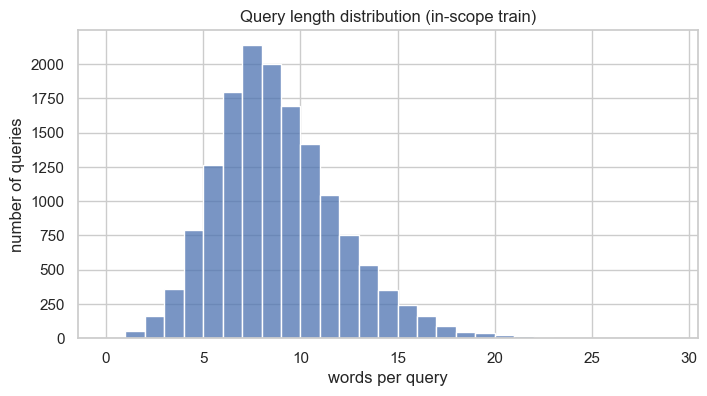

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=range(0, train_df["n_words"].max() + 2))
plt.xlabel("words per query")
plt.ylabel("number of queries")
plt.title("Query length distribution (in-scope train)")
plt.show()

### Vocabulary size

The number of distinct words across the training set. This sets a ceiling for the vectorizer's
vocabulary - the number of TF-IDF features, or the Embedding layer's input dimension.

In [11]:
vocabulary = set()
for text in train_df["text"]:
    vocabulary.update(text.lower().split())

len(vocabulary)

5863

### Example queries per intent

What does the raw text look like? Three examples from the first five intents (alphabetically).

In [12]:
for intent in sorted(train_df["intent"].unique())[:5]:
    print(f"\n=== {intent} ===")
    for text in train_df.loc[train_df["intent"] == intent, "text"].head(3):
        print(" -", text)


=== accept_reservations ===
 - can i make a reservation for redrobin
 - is it possible to make a reservation at redrobin
 - does redrobin take reservations

=== account_blocked ===
 - why is there a hold on my american saving bank account
 - i am nost sure why my account is blocked
 - why is there a hold on my capital one checking account

=== alarm ===
 - wake me up at noon tomorrow
 - set my alarm for getting up
 - make sure my alarm is set for three thirty in the morning

=== application_status ===
 - when will my application for my credit card be processed
 - has the discover card approved my app
 - do you know if my amex card app went through

=== apr ===
 - is the apr on my credit card good
 - how good is the apr on my credit card
 - do i have a good apr on my credit card


### In-scope vs out-of-scope

First some real out-of-scope queries, then a comparison of length distributions. If in-scope and
OOS look similar on the surface, OOS detection must rely on **meaning**, not superficial cues - the
motivation for the confidence-threshold approach.

In [13]:
oos_test_df["text"].head(10).tolist()

['how much has the dow changed today',
 'how many prime numbers are there between 0 and 100',
 'can you tell me how to solve simple algebraic equations with one variable',
 'can you dim the brightness of my screen',
 'what is the account number to the internet service i have',
 'can you see a hdmi cord',
 'what veggies can i pair with mushrooms',
 'can you put the car in fuel efficient mode',
 'at what age can someone get a card',
 "please find today's most read stories from the new york times todayi"]

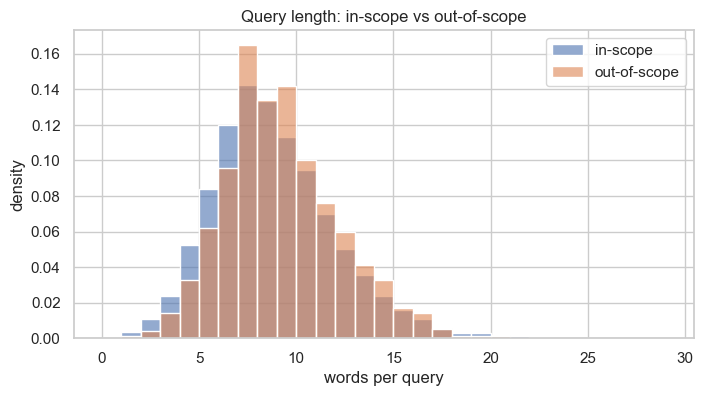

In [14]:
oos_test_df["n_words"] = oos_test_df["text"].str.split().str.len()

plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=range(0, 30), stat="density",
             label="in-scope", color="C0", alpha=0.6)
sns.histplot(oos_test_df["n_words"], bins=range(0, 30), stat="density",
             label="out-of-scope", color="C1", alpha=0.6)
plt.xlabel("words per query")
plt.ylabel("density")
plt.title("Query length: in-scope vs out-of-scope")
plt.legend()
plt.show()